#**DL Assignment 1: Image Classification**
**Group A01 - ML4U Team**  
**Dataset:** [Animals-10 Dataset](https://www.kaggle.com/datasets/alessiocorrado99/animals10/data)

# 1. Download and Import Data

In [ ]:
!mkdir datasets
!curl -L -o ./datasets/dateset.zip\
  https://www.kaggle.com/api/v1/datasets/download/alessiocorrado99/animals10
!unzip -o ./datasets/dateset.zip -d ./datasets/

In [2]:
import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from collections import defaultdict
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import timm
from timm.data import resolve_data_config
from timm.data.transforms_factory import create_transform
import matplotlib.pyplot as plt
import sys
from tqdm.notebook import tqdm
import time
from sklearn.model_selection import train_test_split
import warnings
import copy
import wandb
from tqdm import trange
warnings.filterwarnings("ignore")

In [ ]:
!pip install grad-cam
#!pip install captum -q

In [4]:
# data directories
data_dir = '/content/datasets/raw-img/'
# Italian to English
translate = {"cane": "dog", "cavallo": "horse", "elefante": "elephant", "farfalla": "butterfly", "gallina": "chicken", "gatto": "cat", "mucca": "cow", "pecora": "sheep", "scoiattolo": "squirrel", "dog": "cane", "cavallo": "horse", "elephant" : "elefante", "butterfly": "farfalla", "chicken": "gallina", "cat": "gatto", "cow": "mucca", "spider": "ragno", "squirrel": "scoiattolo","ragno": "spider"}

# 2. EDA (Exploratory Data Analysis)

In [ ]:
#labels name
target_to_class = {v: k for k, v in ImageFolder(data_dir).class_to_idx.items()}
print(f'Label size: {len(target_to_class)}')
target_to_class = {k: translate[v] for k, v in target_to_class.items()}
target_to_class

Label size: 10


{0: 'dog',
 1: 'horse',
 2: 'elephant',
 3: 'butterfly',
 4: 'chicken',
 5: 'cat',
 6: 'cow',
 7: 'sheep',
 8: 'spider',
 9: 'squirrel'}

Some sample image visualization

In [ ]:
# sample image visualization
def show_images(data_dir, batch_size, n=25):
    transform = transforms.Compose([
        transforms.Resize((224,224)),
        transforms.ToTensor(),
    ])
    ds = ImageFolder(data_dir,transform=transform)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=True)
    images, labels = next(iter(loader))
    classes = list(target_to_class.values())
    plt.figure(figsize=(20,20))
    sample = min(n, len(images))
    for i in range(sample):
        plt.subplot(5, 5, i+1)
        img = images[i].permute(1,2,0).numpy()
        plt.imshow(img)
        class_name = classes[labels[i]]
        plt.title(class_name, color='blue', fontsize=12)
        plt.axis("off")
    plt.show()

batch_size = 40
show_images(data_dir,batch_size)

Output hidden; open in https://colab.research.google.com to view.

Label distribution


--- Data Set EDA ---
Total images: 26179
Total classes: 10
Image distribution per class:
    Class  Count
      dog   4863
   spider   4821
  chicken   3098
    horse   2623
butterfly   2112
      cow   1866
 squirrel   1862
    sheep   1820
      cat   1668
 elephant   1446


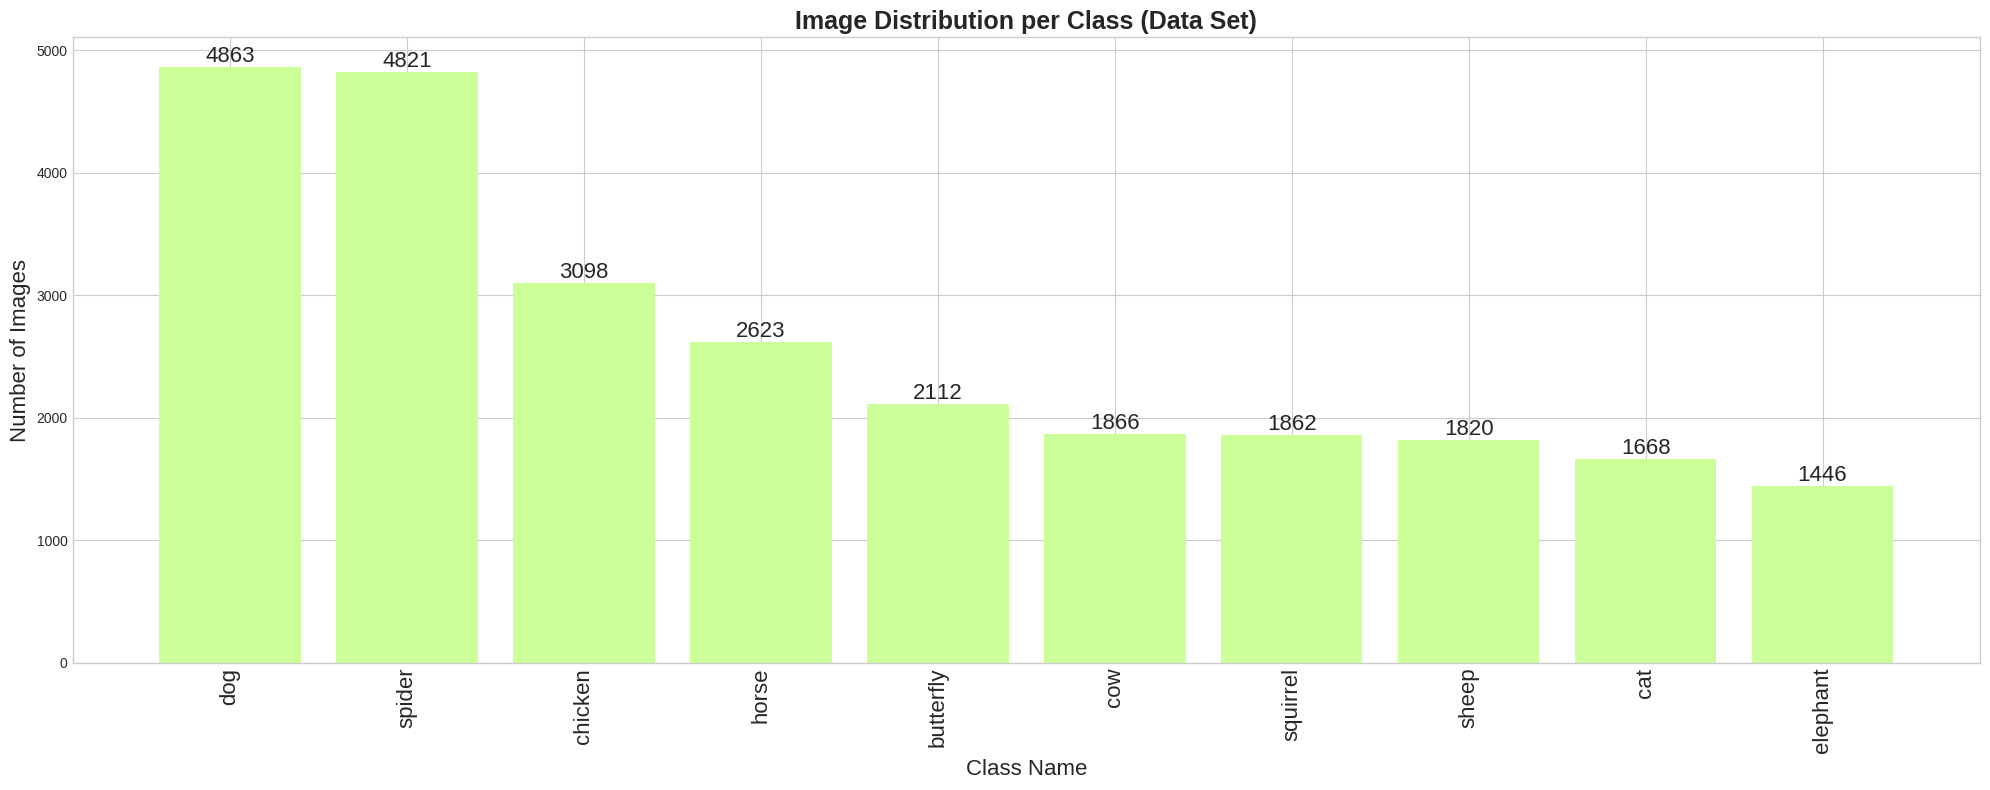

In [ ]:
def perform_eda(data_dir, set_name="Data"):
    """Performs EDA on a specified dataset directory, focusing on label distribution."""
    if not os.path.exists(data_dir):
        print(f"Directory not found: {data_dir}. Skipping EDA for {set_name} set.")
        return

    classes = sorted(os.listdir(data_dir))
    class_counts = {translate[cls]: len(os.listdir(os.path.join(data_dir, cls))) for cls in classes if os.path.isdir(os.path.join(data_dir, cls))}
    total_images = sum(class_counts.values())

    class_df = pd.DataFrame(class_counts.items(), columns=['Class', 'Count'])
    class_df = class_df.sort_values(by='Count', ascending=False)

    print(f'\n--- {set_name} Set EDA ---')
    print(f'Total images: {total_images}')
    print(f'Total classes: {len(classes)}')
    print('Image distribution per class:')
    print(class_df.to_string(index=False))

    plt.style.use('seaborn-v0_8-whitegrid')
    plt.figure(figsize=(20, 8))
    bars = plt.bar(class_df['Class'], class_df['Count'], color='#CCFF99')

    plt.title(f'Image Distribution per Class ({set_name} Set)', fontsize=18, fontweight='bold')
    plt.xlabel('Class Name', fontsize=16)
    plt.ylabel('Number of Images', fontsize=16)
    plt.xticks(rotation=90, fontsize=16)

    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width() / 2., height,
                 '%d' % int(height), ha='center', va='bottom', fontsize=16)

    plt.tight_layout()
    plt.show()

perform_eda(data_dir)

# 3. Modeling

In [5]:
import random
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SAVE_DIR = "/content/saved_models"
NUM_CLASSES = 10
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_EPOCHS = 15
LR = 1e-4
os.makedirs(SAVE_DIR, exist_ok=True)
WANDB_PROJECT = "animals10-DL1"
WANDB_ENTITY  = None
WANDB_ENABLED = True

In [6]:
TRAIN_MODEL = False

## 3.1 Data Splits

In [7]:
class AnimalDataset(Dataset):
    def __init__(self, root, indices=None, transform=None, translate_map=None):
        self.base_ds = ImageFolder(root)
        self.transform = transform
        self.translate_map = translate_map or {}

        # build English class names
        self.idx_to_class = {
            v: self.translate_map.get(k, k)
            for k, v in self.base_ds.class_to_idx.items()
        }

        if indices is not None:
            self.indices = indices
        else:
            self.indices = list(range(len(self.base_ds)))

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        real_idx = self.indices[i]
        img_path, label = self.base_ds.samples[real_idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

    @property
    def classes(self):
        return [self.idx_to_class[i] for i in range(NUM_CLASSES)]

In [8]:
from timm.data import resolve_data_config
from timm.data.transforms_factory import create_transform

def make_splits(root: str, train_ratio=0.70, val_ratio=0.15, seed=SEED):
    base = ImageFolder(root)
    labels  = [s[1] for s in base.samples]
    indices = list(range(len(labels)))

    train_idx, temp_idx, y_train, y_temp = train_test_split(
        indices, labels,
        test_size=1 - train_ratio,
        stratify=labels,
        random_state=seed
    )
    rel_val = val_ratio / (1 - train_ratio)
    val_idx, test_idx, _, _ = train_test_split(
        temp_idx, y_temp,
        test_size=1 - rel_val,
        stratify=y_temp,
        random_state=seed
    )
    print(f"Split sizes → train: {len(train_idx)}, val: {len(val_idx)}, test: {len(test_idx)}")
    return train_idx, val_idx, test_idx

def get_transforms(model_key, augment=False):
    model = timm.create_model(MODEL_ZOO[model_key], pretrained=False)
    data_config = resolve_data_config({}, model=model)

    mean = data_config["mean"]
    std  = data_config["std"]

    if augment:
        transform = transforms.Compose([
            transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(p=0.1),
            transforms.ColorJitter(brightness=0.3, contrast=0.3,
                                   saturation=0.2, hue=0.1),
            transforms.RandomRotation(20),
            transforms.RandomGrayscale(p=0.05),
            transforms.ToTensor(),
            transforms.Normalize(mean=mean, std=std),
        ])
    else:
        transform = transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.ToTensor(),
            transforms.Normalize(mean=mean, std=std),
        ])
    return transform

def build_loaders(root, train_idx, val_idx, test_idx, model_key, augment=False):
    train_tf = get_transforms(model_key, augment=augment)
    eval_tf  = get_transforms(model_key, augment=False)

    train_ds = AnimalDataset(root, train_idx, transform=train_tf,  translate_map=translate)
    val_ds   = AnimalDataset(root, val_idx,   transform=eval_tf, translate_map=translate)
    test_ds  = AnimalDataset(root, test_idx,  transform=eval_tf, translate_map=translate)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=2, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=2, pin_memory=True)
    return train_loader, val_loader, test_loader

In [9]:
train_idx, val_idx, test_idx = make_splits(data_dir)
CLASS_NAMES = AnimalDataset(data_dir, translate_map=translate).classes

Split sizes → train: 18325, val: 3926, test: 3928


## 3.2 Training

In [10]:
class AnimalClassifier(nn.Module):
    def __init__(self, timm_name, n_classes, hidden_dim=512):
        super().__init__()
        self.backbone = timm.create_model(timm_name, pretrained=True, num_classes=0)
        in_features = self.get_in_features()
        self.head = nn.Sequential(
            nn.Linear(in_features,hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim,n_classes)
        )

    def get_in_features(self):
        self.backbone.eval()
        dummy  = torch.zeros(2, 3, 224, 224)
        out = self.backbone(dummy)
        return out.shape[-1]

    def forward(self, x):
        x = self.backbone(x)
        return self.head(x)

In [11]:
MODEL_ZOO = {
    # name            : timm_model_name
    "ResNet18"        : "resnet18",
    "EfficientNetB0"  : "efficientnet_b0",
    "ViT_B16"         : "vit_base_patch16_224",
    "SwinT"           : "swin_tiny_patch4_window7_224",
     # "DeiT_S"          : "deit_small_patch16_224",
}

def build_model(model_key: str, num_classes=NUM_CLASSES, pretrained=True):
    """Load a timm model and replace the classifier head."""
    timm_name = MODEL_ZOO[model_key]
    # model = timm.create_model(timm_name, pretrained=pretrained, num_classes=num_classes)
    model = AnimalClassifier(timm_name, num_classes)
    return model.to(DEVICE)

In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
def train_one_epoch(model, loader, criterion, optimizer, scaler=None,
                    epoch=0, num_epochs=0, tag=""):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    pbar = tqdm(loader,
                desc=f"  [Train] {tag} Ep {epoch}/{num_epochs}",
                leave=False, dynamic_ncols=True,
                bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt}"
                           " [{elapsed}<{remaining}, {rate_fmt}]")

    for imgs, labels in pbar:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        if scaler is not None:
            with torch.cuda.amp.autocast():
                outputs = model(imgs)
                loss    = criterion(outputs, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(imgs)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

        running_loss   += loss.item() * imgs.size(0)
        preds           = outputs.argmax(dim=1)
        batch_correct   = (preds == labels).sum().item()
        correct        += batch_correct
        total          += imgs.size(0)

        pbar.set_postfix(
            loss=f"{loss.item():.4f}",
            acc=f"{batch_correct / imgs.size(0) * 100:.1f}%"
        )

    pbar.close()
    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, desc="  [Val]  "):
    model.eval()
    running_loss = 0.0
    all_preds, all_labels = [], []

    pbar = tqdm(loader, desc=desc, leave=False, dynamic_ncols=True,
                bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt}"
                           " [{elapsed}<{remaining}, {rate_fmt}]")

    for imgs, labels in pbar:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        outputs      = model(imgs)
        loss         = criterion(outputs, labels)
        running_loss += loss.item() * imgs.size(0)
        preds         = outputs.argmax(dim=1)
        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    pbar.close()

    all_preds  = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()

    metrics = {
        "acc"           : accuracy_score(all_labels, all_preds),
        "precision"     : precision_score(all_labels, all_preds, average="macro", zero_division=0),
        "recall"        : recall_score(all_labels, all_preds,    average="macro", zero_division=0),
        "f1"            : f1_score(all_labels, all_preds,        average="macro", zero_division=0),
        # per-class arrays for heatmap / breakdown
        "prec_per_class": precision_score(all_labels, all_preds, average=None, zero_division=0),
        "rec_per_class" : recall_score(all_labels, all_preds,    average=None, zero_division=0),
        "f1_per_class"  : f1_score(all_labels, all_preds,        average=None, zero_division=0),
    }
    return running_loss / len(all_labels), metrics

In [13]:
def run_experiment(model_key, train_loader, val_loader, test_loader,
                   augment_flag, num_epochs=NUM_EPOCHS):
    tag        = f"{model_key}_{'aug' if augment_flag else 'noaug'}"
    aug_label  = "w/ augmentation" if augment_flag else "no augmentation"

    print(f"\n{'='*60}")
    print(f"  Experiment : {tag}  ({aug_label})")
    print(f"{'='*60}")

    # W&B run
    run = None
    if WANDB_ENABLED:
        run = wandb.init(
            project=WANDB_PROJECT,
            entity=WANDB_ENTITY,
            name=tag,
            group=model_key,
            tags=[model_key, "aug" if augment_flag else "noaug"],
            config={
                "model"       : model_key,
                "timm_name"   : MODEL_ZOO[model_key],
                "augmentation": augment_flag,
                "num_epochs"  : num_epochs,
                "batch_size"  : BATCH_SIZE,
                "lr"          : LR,
                "img_size"    : IMG_SIZE,
                "num_classes" : NUM_CLASSES,
                "optimizer"   : "AdamW",
                "scheduler"   : "CosineAnnealingLR",
                "label_smooth": 0.1,
                "seed"        : SEED,
            },
            reinit=True,
        )

    # Model, criterion, optimiser
    model     = build_model(model_key)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    scaler    = torch.cuda.amp.GradScaler() if DEVICE.type == "cuda" else None

    if run is not None:
        wandb.watch(model, criterion, log="gradients", log_freq=50)

    history      = {
        "train_loss": [], "train_acc": [],
        "val_loss"  : [], "val_acc"  : [],
        "val_prec"  : [], "val_rec"  : [], "val_f1": [],
    }
    best_val_f1  = 0.0
    best_weights = None

    # Epoch loop
    epoch_bar = trange(1, num_epochs + 1,
                       desc=f"  {tag}",
                       unit="epoch",
                       dynamic_ncols=True,
                       bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} epochs"
                                  " [{elapsed}<{remaining}]  {postfix}")

    for epoch in epoch_bar:
        t0 = time.time()

        # train
        tl, ta = train_one_epoch(model, train_loader, criterion, optimizer,
                                 scaler, epoch=epoch, num_epochs=num_epochs,
                                 tag=tag)

        # validate
        vl, vm = evaluate(model, val_loader, criterion,
                          desc=f"  [Val]   {tag} Ep {epoch}/{num_epochs}")
        va, vp, vr, vf = vm["acc"], vm["precision"], vm["recall"], vm["f1"]

        scheduler.step()
        elapsed = time.time() - t0
        lr_now  = scheduler.get_last_lr()[0]

        history["train_loss"].append(tl)
        history["train_acc"].append(ta)
        history["val_loss"].append(vl)
        history["val_acc"].append(va)
        history["val_prec"].append(vp)
        history["val_rec"].append(vr)
        history["val_f1"].append(vf)

        epoch_bar.set_postfix(
            tr_loss=f"{tl:.4f}", tr_acc=f"{ta*100:.1f}%",
            vl_f1  =f"{vf*100:.1f}%", vl_acc=f"{va*100:.1f}%",
            vl_rec =f"{vr*100:.1f}%",
            lr=f"{lr_now:.2e}", time=f"{elapsed:.1f}s"
        )

        # W&B logging
        if run is not None:
            wandb.log({
                "epoch"          : epoch,
                "train/loss"     : tl,
                "train/acc"      : ta * 100,
                "val/loss"       : vl,
                "val/acc"        : va * 100,
                "val/precision"  : vp * 100,
                "val/recall"     : vr * 100,
                "val/f1"         : vf * 100,
                "lr"             : lr_now,
                "epoch_time_sec" : elapsed,
            }, step=epoch)

        # checkpoint
        if vf > best_val_f1:
            best_val_f1  = vf
            best_weights = copy.deepcopy(model.state_dict())

    epoch_bar.close()

    # Test
    model.load_state_dict(best_weights)
    _, tm = evaluate(model, test_loader, criterion,
                     desc=f"  [Test]  {tag}")
    test_acc, test_prec, test_rec, test_f1 = (
        tm["acc"], tm["precision"], tm["recall"], tm["f1"])

    print(f"\n -> Best val F1    : {best_val_f1*100:.2f}%")
    print(f" -> Test Acc       : {test_acc*100:.2f}%")
    print(f" -> Test Precision : {test_prec*100:.2f}%  (macro)")
    print(f" -> Test Recall    : {test_rec*100:.2f}%  (macro)")
    print(f" -> Test F1        : {test_f1*100:.2f}%  (macro)")

    # per-class breakdown
    print(f"\n  Per-class F1:")
    for i, name in enumerate(CLASS_NAMES):
        print(f"    {name:<12} F1={tm['f1_per_class'][i]*100:.1f}%  "
              f"P={tm['prec_per_class'][i]*100:.1f}%  "
              f"R={tm['rec_per_class'][i]*100:.1f}%")

    # Save checkpoint
    save_path = os.path.join(SAVE_DIR, f"{tag}.pth")
    torch.save({
        "model_key" : model_key,
        "state_dict": best_weights,
        "test_acc"  : test_acc,
        "test_prec" : test_prec,
        "test_rec"  : test_rec,
        "test_f1"   : test_f1,
    }, save_path)
    print(f"  Saved → {save_path}")

    if run is not None:
        wandb.summary["best_val_f1"]   = best_val_f1  * 100
        wandb.summary["test_acc"]      = test_acc      * 100
        wandb.summary["test_precision"]= test_prec     * 100
        wandb.summary["test_recall"]   = test_rec      * 100
        wandb.summary["test_f1"]       = test_f1       * 100

        wandb.log({"test/per_class_metrics": wandb.Table(
            columns=["class", "precision", "recall", "f1"],
            data=[[CLASS_NAMES[i],
                   round(tm["prec_per_class"][i]*100, 2),
                   round(tm["rec_per_class"][i]*100, 2),
                   round(tm["f1_per_class"][i]*100, 2)]
                  for i in range(NUM_CLASSES)]
        )})

        artifact = wandb.Artifact(
            name=f"model-{tag}", type="model",
            description=f"Best checkpoint for {tag}",
            metadata={"test_f1": test_f1, "test_acc": test_acc},
        )
        artifact.add_file(save_path)
        run.log_artifact(artifact)
        run.finish()

    history["test_acc"]      = test_acc
    history["test_prec"]     = test_prec
    history["test_rec"]      = test_rec
    history["test_f1"]       = test_f1
    history["best_val_f1"]   = best_val_f1
    return history, model

In [14]:
if TRAIN_MODEL:

    if WANDB_ENABLED:
        wandb.login('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')
        print(f"W&B project : {WANDB_PROJECT}")

    all_results   = {}   # tag → history
    experiments   = [(mk, aug) for mk in MODEL_ZOO for aug in [False, True]]
    total_runs    = len(experiments)

    outer_bar = tqdm(experiments, desc="All experiments",
                    unit="run", dynamic_ncols=True,
                    bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} runs"
                                " [{elapsed}<{remaining}]  {postfix}")

    for model_key, augment in outer_bar:
        tag = f"{model_key}_{'aug' if augment else 'noaug'}"
        outer_bar.set_postfix(current=tag)

        train_loader, val_loader, test_loader = build_loaders(
            data_dir, train_idx, val_idx, test_idx, model_key=model_key, augment=augment)
        history, _ = run_experiment(
            model_key, train_loader, val_loader, test_loader, augment)
        all_results[tag] = history

    outer_bar.close()
    print("\n Training doned.")

In [15]:
# if not TRAIN:
    #load results

In [16]:
import gdown
MODEL_LINK = {
    # name            : timm_model_name
    "ResNet18_aug"        : "https://drive.google.com/file/d/16u1Rw2GypIfRfZebLqWghcMfz_spU1n1/view?usp=drive_link",
    "ResNet18_noaug"        : "https://drive.google.com/file/d/1bRYZ6_fPFi2ILeSEDnMpR-CrkMgi8jvp/view?usp=drive_link",
    "EfficientNetB0_aug"  : "https://drive.google.com/file/d/1vkVrf7_uKNlxGF22ti0DLbJ9GJaayToT/view?usp=drive_link",
    "EfficientNetB0_noaug"  : "https://drive.google.com/file/d/1Lna7zpX9eft3z_E3-lybAS10BzcHD_sr/view?usp=drive_link",
    "ViT_B16_aug"         : "https://drive.google.com/file/d/1FNol6EEdFxqg4tv7ZDbwrDMlfrJ5aovp/view?usp=drive_link",
    "ViT_B16_noaug"         : "https://drive.google.com/file/d/1EkeGYrZBkFlCQ09w_G2L2o6eL8w0GIjv/view?usp=drive_link",
    "SwinT_aug"           : "https://drive.google.com/file/d/1OjNtxEbKyKS7miK7ewX2EAjqKuk2KIkS/view?usp=drive_link",
    "SwinT_noaug"           : "https://drive.google.com/file/d/1t_RXspZXHh75wmDUkDEf4HJZjgkCxthS/view?usp=drive_link"
}
# MODEL_PATH = "/content/efficientnetB0_aug.pth"
def download_model():
    for name, url in MODEL_LINK.items():
        output_file = f'./{name}.pth'
        gdown.download(url, output=output_file, fuzzy=True)

if TRAIN_MODEL == False:
    download_model()
    gdown.download("https://drive.google.com/file/d/1EDys_LZYHOzZw-aSagBO5YeBQret4eYB/view?usp=drive_link", output='./results_summary.csv', fuzzy=True)

Downloading...
From (original): https://drive.google.com/uc?id=16u1Rw2GypIfRfZebLqWghcMfz_spU1n1
From (redirected): https://drive.google.com/uc?id=16u1Rw2GypIfRfZebLqWghcMfz_spU1n1&confirm=t&uuid=e5100901-a66d-48ea-8b99-2754594e9fa5
To: /content/ResNet18_aug.pth
100%|██████████| 45.9M/45.9M [00:00<00:00, 48.0MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1bRYZ6_fPFi2ILeSEDnMpR-CrkMgi8jvp
From (redirected): https://drive.google.com/uc?id=1bRYZ6_fPFi2ILeSEDnMpR-CrkMgi8jvp&confirm=t&uuid=764ac25d-d153-44c2-bc45-ef5b90ed0d9c
To: /content/ResNet18_noaug.pth
100%|██████████| 45.9M/45.9M [00:00<00:00, 49.8MB/s]
Downloading...
From: https://drive.google.com/uc?id=1vkVrf7_uKNlxGF22ti0DLbJ9GJaayToT
To: /content/EfficientNetB0_aug.pth
100%|██████████| 19.0M/19.0M [00:00<00:00, 37.9MB/s]
Downloading...
From: https://drive.google.com/uc?id=1Lna7zpX9eft3z_E3-lybAS10BzcHD_sr
To: /content/EfficientNetB0_noaug.pth
100%|██████████| 19.0M/19.0M [00:00<00:00, 76.0MB/s]
Downloading...

## 3.3 Train Results

In [23]:
gdown.download("https://drive.google.com/file/d/19UAsXlHKbs_wEB-vw2Px0ZkzIQhq13Uj/view?usp=sharing", output='./test.png', fuzzy=True)

Downloading...
From: https://drive.google.com/uc?id=19UAsXlHKbs_wEB-vw2Px0ZkzIQhq13Uj
To: /content/test.png
100%|██████████| 158k/158k [00:00<00:00, 50.2MB/s]


'./test.png'

In [19]:
import gdown
gdown.download_folder("https://drive.google.com/drive/folders/1LzPi5EIt_iAG0qm4JDD8YSf8JmWlpICl", output="./confusion_img", quiet=True)

['./confusion_img/confusion_matrix_EfficientNetB0_aug.png',
 './confusion_img/confusion_matrix_EfficientNetB0_noaug.png',
 './confusion_img/confusion_matrix_ResNet18_aug.png',
 './confusion_img/confusion_matrix_ResNet18_noaug.png',
 './confusion_img/confusion_matrix_SwinT_aug.png',
 './confusion_img/confusion_matrix_SwinT_noaug.png',
 './confusion_img/confusion_matrix_ViT_B16_aug.png',
 './confusion_img/confusion_matrix_ViT_B16_noaug.png']

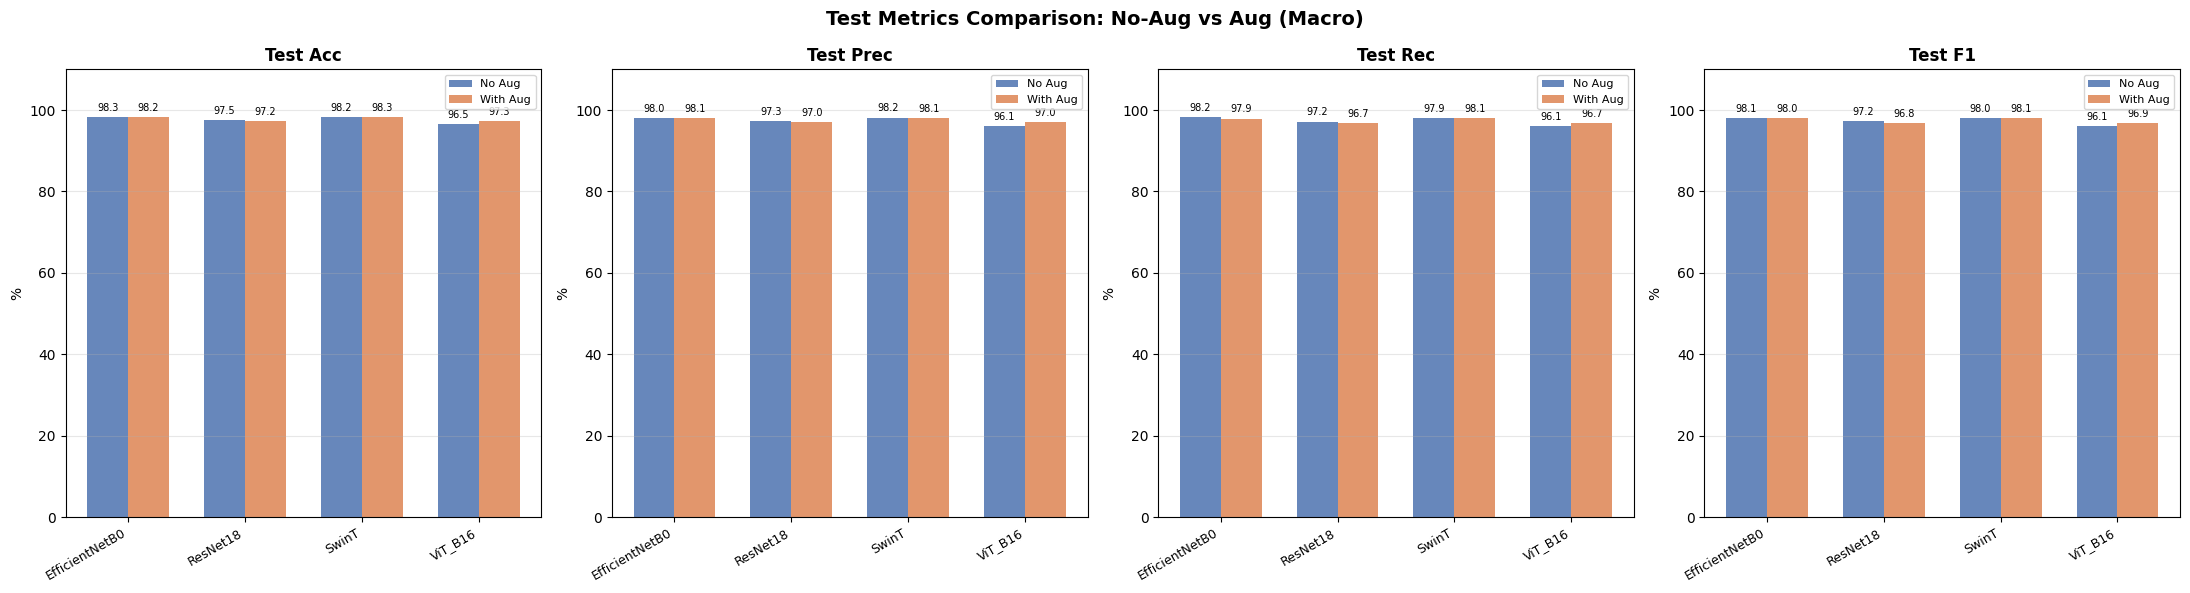

In [17]:
def plot_comparison_bar(results_df, save_path=None):
    metrics   = ["Test Acc (%)", "Test Prec (%)", "Test Rec (%)", "Test F1 (%)"]
    aug_vals  = results_df[results_df["Augmentation"] == True].set_index("Model")
    noaug_vals= results_df[results_df["Augmentation"] == False].set_index("Model")
    models    = aug_vals.index.tolist()

    fig, axes = plt.subplots(1, 4, figsize=(22, 6), sharey=False)
    fig.suptitle("Test Metrics Comparison: No-Aug vs Aug (Macro)", fontsize=14,
                 fontweight="bold")

    colors = {"No Aug": "#4C72B0", "With Aug": "#DD8452"}
    x      = np.arange(len(models))
    width  = 0.35

    for ax, metric in zip(axes, metrics):
        b1 = ax.bar(x - width/2,
                    [noaug_vals.loc[m, metric] for m in models],
                    width, label="No Aug",   color=colors["No Aug"],   alpha=0.85)
        b2 = ax.bar(x + width/2,
                    [aug_vals.loc[m, metric]   for m in models],
                    width, label="With Aug", color=colors["With Aug"], alpha=0.85)
        for bar in [*b1, *b2]:
            h = bar.get_height()
            ax.annotate(f'{h:.1f}',
                        xy=(bar.get_x() + bar.get_width()/2, h),
                        xytext=(0, 3), textcoords="offset points",
                        ha='center', va='bottom', fontsize=7)
        ax.set_title(metric.replace(" (%)", ""), fontweight="bold")
        ax.set_ylabel("%")
        ax.set_xticks(x)
        ax.set_xticklabels(models, rotation=30, ha="right", fontsize=9)
        ax.legend(fontsize=8)
        ax.grid(axis="y", alpha=0.3)
        ax.set_ylim(0, 110)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

results_df = pd.read_csv("./results_summary.csv")
plot_comparison_bar(results_df,
                    save_path=os.path.join(SAVE_DIR, "comparison_bar.png"))

In [18]:
def load_saved_model(name):
    path = f'./{name}.pth'
    checkpoint = torch.load(path, map_location=DEVICE)
    model_key  = checkpoint["model_key"]

    model      = build_model(model_key, pretrained=False)
    model.load_state_dict(checkpoint["state_dict"])
    model.eval()
    return model, model_key

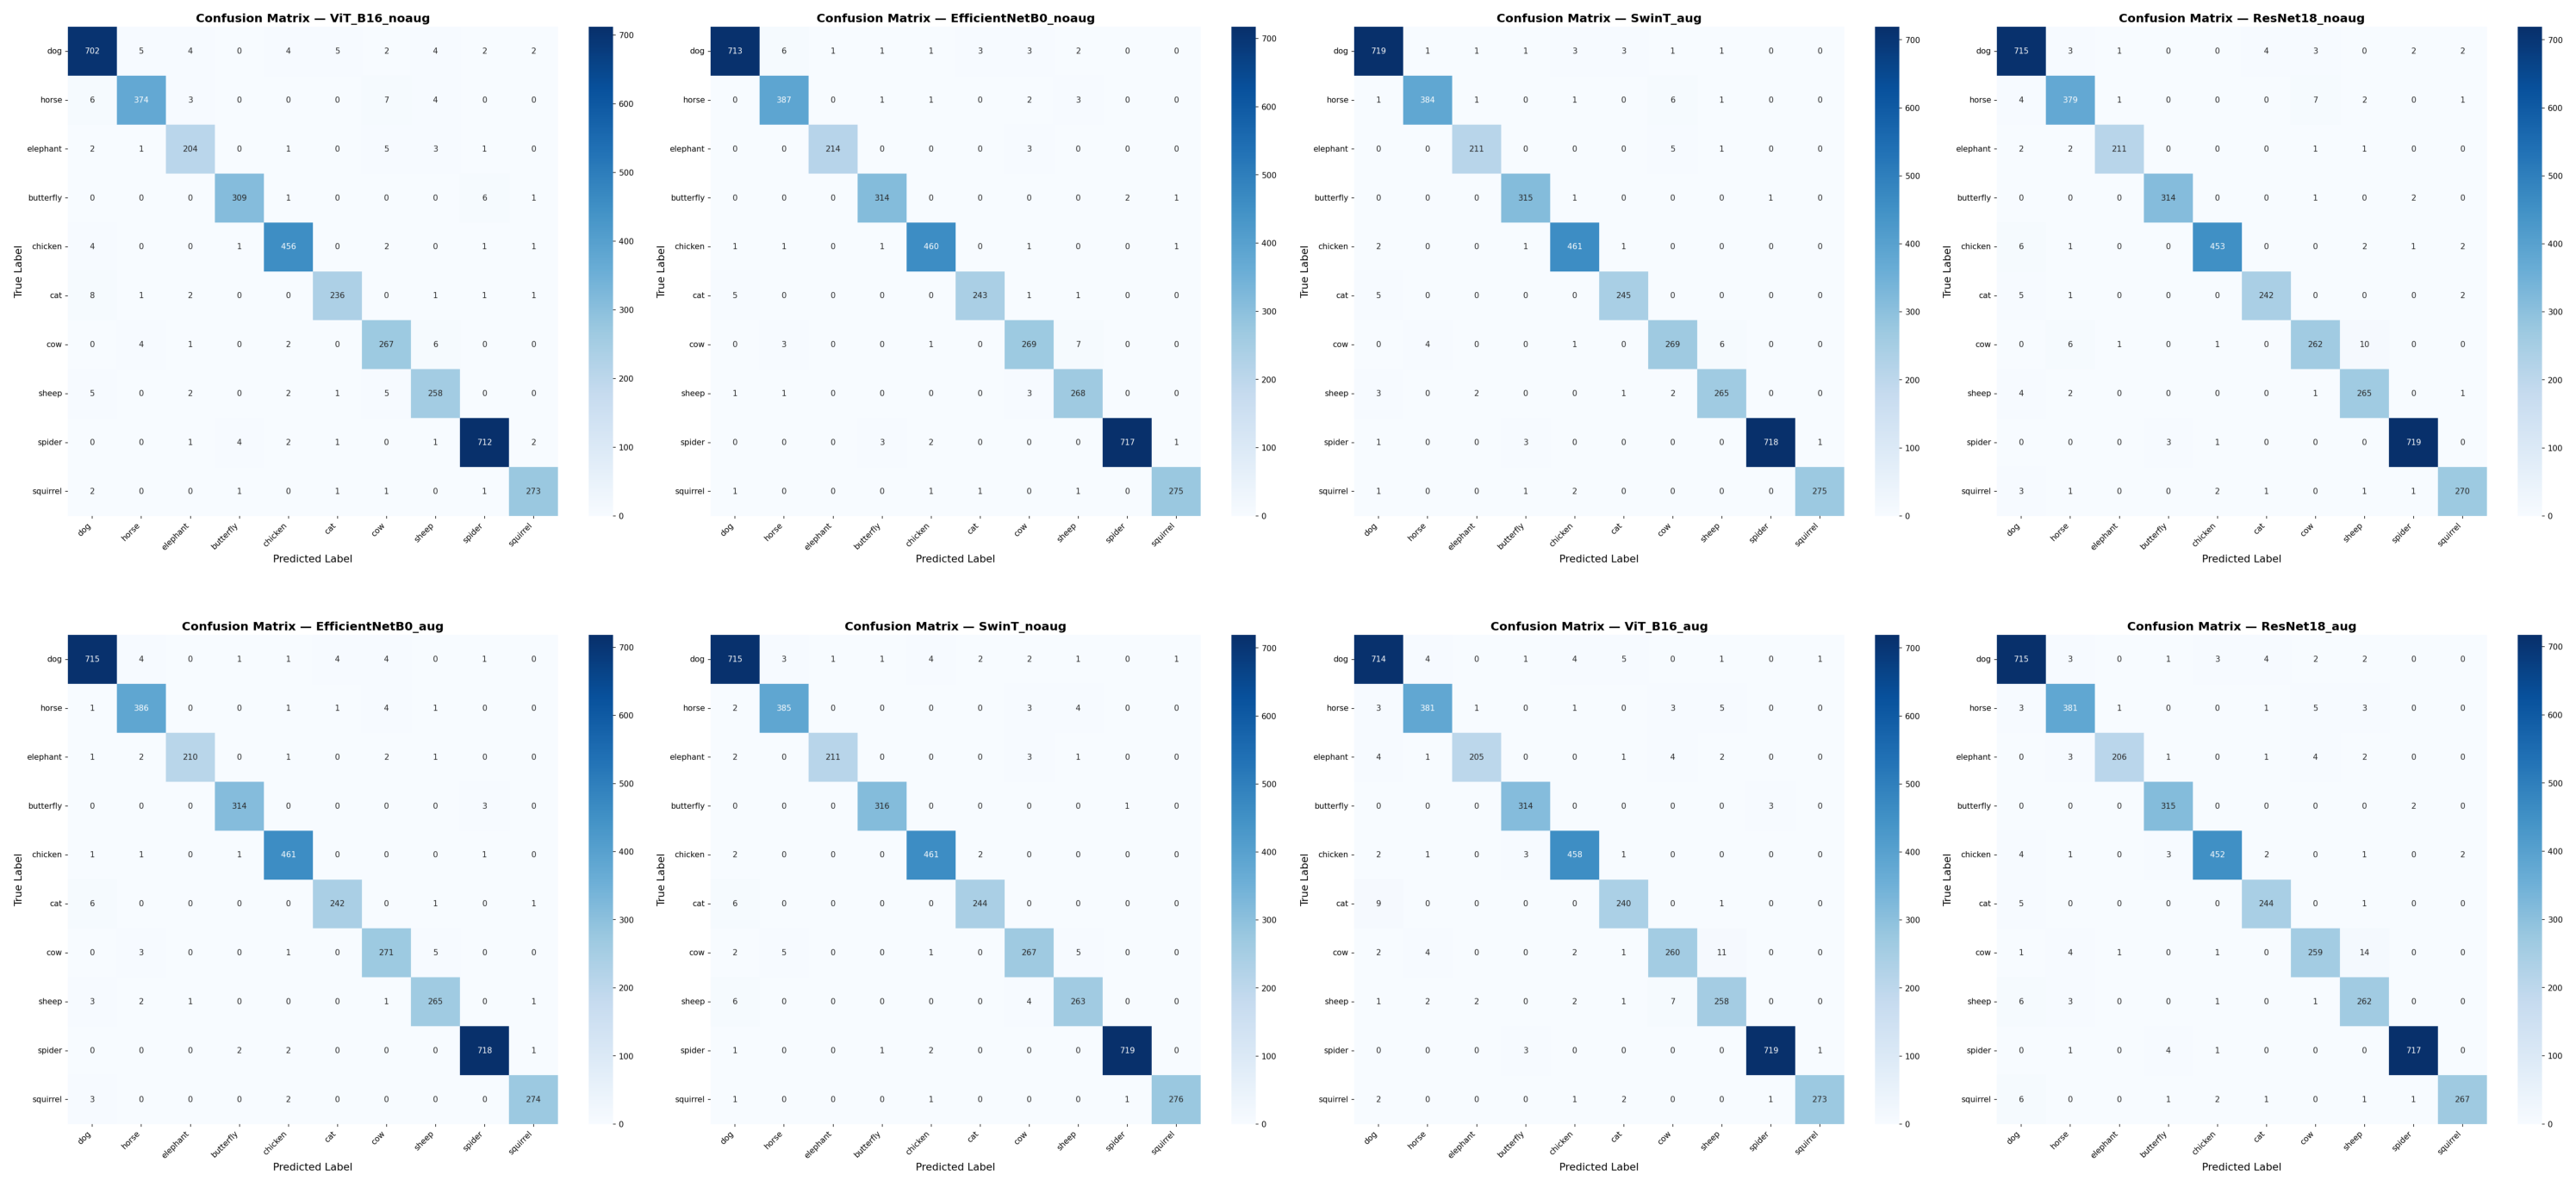

In [20]:
import matplotlib.image as mpimg

img_files = [f for f in os.listdir('./confusion_img') if f.endswith(".png")]
fig, axes = plt.subplots(2, 4, figsize=(15*2, 15))

for i, file_name in enumerate(img_files):
    ax = axes[i//4][i%4]
    img_path = os.path.join('./confusion_img', file_name)
    img = mpimg.imread(img_path)
    ax.imshow(img)
    ax.axis('off')

    ax.set_xlabel('Predicted Label', fontsize=13)
    ax.set_ylabel('True Label', fontsize=13)

plt.tight_layout()
plt.show()

In [21]:
model, model_key = load_saved_model('EfficientNetB0_noaug')
test_ds  = AnimalDataset(data_dir, test_idx,  transform=None, translate_map=translate)

num_samples = 25
random_indices = random.sample(range(len(test_ds)), num_samples)

fig, axes = plt.subplots(5, 5, figsize=(20, 20))
axes = axes.ravel()
transform = get_transforms(model_key,False)
with torch.no_grad():
    for i, idx in enumerate(random_indices):

        image_pil, true_label = test_ds[idx]
        image_transformed = transform(image_pil).unsqueeze(0).to(DEVICE)


        output = model(image_transformed)
        _, predicted_label = torch.max(output, 1)
        predicted_label = predicted_label.item()
        pred_conf = output.softmax(dim=1)[0, predicted_label].item()

        true_class = test_ds.classes[true_label]
        pred_class = test_ds.classes[predicted_label]

        axes[i].imshow(image_pil)
        axes[i].axis('off')

        color = 'green' if true_label == predicted_label else 'red'
        axes[i].set_title(f'True: {true_class}\nPred: {pred_class} - Conf: {pred_conf:.3f}',
                         color=color, fontsize=10)

plt.tight_layout()
plt.suptitle('Model Predictions on Test Data', fontsize=16, y=1.002)
plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [22]:
def infer(img_path,model_name):
    image = Image.open(img_path).convert("RGB")
    image_transformed = transform(image).unsqueeze(0).to(DEVICE)
    model, _ = load_saved_model(model_name)
    output = model(image_transformed)
    _, predicted_label = torch.max(output, 1)
    predicted_label = predicted_label.item()
    pred_conf = output.softmax(dim=1)[0, predicted_label].item()
    pred_class = CLASS_NAMES[predicted_label]
    return pred_class, pred_conf

In [24]:
#collect failed samples
model, model_key = load_saved_model('EfficientNetB0_noaug')
test_ds  = AnimalDataset(data_dir, test_idx, transform=None, translate_map=translate)

transform = get_transforms(model_key, False)

correct_idx = []
wrong_idx = []

with torch.no_grad():
    for idx in range(len(test_ds)):
        image_pil, true_label = test_ds[idx]
        image_transformed = transform(image_pil).unsqueeze(0).to(DEVICE)

        output = model(image_transformed)
        _, predicted_label = torch.max(output, 1)
        predicted_label = predicted_label.item()

        if predicted_label == true_label:
            if len(correct_idx) < 25:
                correct_idx.append(idx)
        else:
            if len(wrong_idx) < 25:
                wrong_idx.append(idx)

        if len(correct_idx) == 25 and len(wrong_idx) == 25:
            break

print(f"Collected {len(correct_idx)} correct and {len(wrong_idx)} wrong samples")

Collected 25 correct and 25 wrong samples


In [25]:
import math
n = len(wrong_idx)
cols = 5
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
axes = axes.flatten()

with torch.no_grad():
    for i, idx in enumerate(wrong_idx):
        ax = axes[i]

        image_pil, true_label = test_ds[idx]
        image_transformed = transform(image_pil).unsqueeze(0).to(DEVICE)

        output = model(image_transformed)
        probs = output.softmax(dim=1)

        pred_label = probs.argmax(dim=1).item()
        pred_conf = probs[0, pred_label].item()

        true_class = test_ds.classes[true_label]
        pred_class = test_ds.classes[pred_label]

        ax.imshow(image_pil)
        ax.axis('off')

        ax.set_title(
            f'True: {true_class}\nPred: {pred_class} - Conf: {pred_conf:.3f}',
            color='red',
            fontsize=10
        )

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
#plt.suptitle('Misclassified Samples', fontsize=16)
plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [26]:
# !pip install thop -q

# from thop import profile
# import os

In [27]:
# def compute_params_flops(model_key):
#     model = build_model(model_key, pretrained=False)
#     model.eval().to(DEVICE)
#     dummy = torch.zeros(1, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
#     flops, params = profile(model, inputs=(dummy,), verbose=False)

#     tmp_path = f"/tmp/_tmp_{model_key}.pth"
#     torch.save(model.state_dict(), tmp_path)
#     size_mb = os.path.getsize(tmp_path) / 1e6
#     os.remove(tmp_path)

#     return int(params), int(flops), round(size_mb, 2)

# model_metrics = {}
# for model_key in MODEL_ZOO:
#     params, flops, size_mb = compute_params_flops(model_key)
#     model_metrics[model_key] = {
#         "Total Params (M)": round(params / 1e6, 2),
#         "Inference FLOPs (G)": round(flops / 1e9, 2),
#         "Model Size (MB)": size_mb,
#     }
#     print(f"{model_key:20s} | Params: {params/1e6:.2f}M | FLOPs: {flops/1e9:.2f}G | Size: {size_mb:.2f}MB")

# results_df = pd.read_csv("./results_summary.csv")
# results_df["Total Params (M)"]    = results_df["Model"].map(lambda m: model_metrics[m]["Total Params (M)"])
# results_df["Inference FLOPs (G)"] = results_df["Model"].map(lambda m: model_metrics[m]["Inference FLOPs (G)"])
# results_df["Model Size (MB)"]     = results_df["Model"].map(lambda m: model_metrics[m]["Model Size (MB)"])

# results_df.to_csv("./results_summary.csv", index=False)
# print("\nĐã merge xong vào results_summary.csv:")
# print(results_df.to_string(index=False))

# 4. Visualize result

In [ ]:
import cv2
import torch.nn.functional as F
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

def preprocess_image(img_path):
    image = Image.open(img_path).convert("RGB")

    img_resized = image.resize((224, 224))
    img_float = np.float32(img_resized) / 255.0

    return image, img_resized, img_float

def compare_saliency(model1, model2, model1_name, model2_name, img_path, class_names, transform):
    model1.eval()
    model2.eval()

    image, img_resized, _ = preprocess_image(img_path)

    input_tensor = transform(image).unsqueeze(0).to(DEVICE)

    input1 = input_tensor.clone().detach().requires_grad_(True)
    input2 = input_tensor.clone().detach().requires_grad_(True)

    # ---- MODEL 1 ----
    out1 = model1(input1)
    pred1 = out1.argmax(dim=1).item()
    score1 = out1[0, pred1]

    model1.zero_grad()
    score1.backward()

    sal1, _ = torch.max(input1.grad.abs(), dim=1)
    sal1 = sal1.squeeze().cpu().numpy()

    # ---- MODEL 2 ----
    out2 = model2(input2)
    pred2 = out2.argmax(dim=1).item()
    score2 = out2[0, pred2]

    model2.zero_grad()
    score2.backward()

    sal2, _ = torch.max(input2.grad.abs(), dim=1)
    sal2 = sal2.squeeze().cpu().numpy()

    # ---- PLOT ----
    fig, ax = plt.subplots(1,3, figsize=(15,5))

    ax[0].imshow(img_resized)
    ax[0].axis("off")
    ax[0].set_title("Original")

    ax[1].imshow(sal1, cmap="hot")
    ax[1].axis("off")
    ax[1].set_title(f"{model1_name}: {class_names[pred1]}")

    ax[2].imshow(sal2, cmap="hot")
    ax[2].axis("off")
    ax[2].set_title(f"{model2_name}: {class_names[pred2]}")

    plt.tight_layout()
    plt.show()

In [ ]:
def get_target_layer(model, model_key):
    if "EfficientNet" in model_key:
        return [model.backbone.conv_head]

    elif "ResNet" in model_key:
        return [model.backbone.layer4[-1]]

    else:
        raise ValueError("Unsupported architecture")

def compare_gradcam(model1, key1, model1_name, model2, key2, model2_name, img_path, true_label, transform):

    model1.eval()
    model2.eval()

    image, _, img_float = preprocess_image(img_path)

    input_tensor = transform(image).unsqueeze(0).to(DEVICE)

    # ---- MODEL 1 ----
    target_layers1 = get_target_layer(model1, key1)
    cam1 = GradCAM(model=model1, target_layers=target_layers1)

    grayscale_cam1 = cam1(input_tensor=input_tensor)[0]
    cam_img1 = show_cam_on_image(img_float, grayscale_cam1, use_rgb=True)

    out1 = model1(input_tensor)
    pred1 = out1.argmax(dim=1).item()
    pred_conf1 = out1.softmax(dim=1)[0, pred1].item()

    # ---- MODEL 2 ----
    target_layers2 = get_target_layer(model2, key2)
    cam2 = GradCAM(model=model2, target_layers=target_layers2)

    grayscale_cam2 = cam2(input_tensor=input_tensor)[0]
    cam_img2 = show_cam_on_image(img_float, grayscale_cam2, use_rgb=True)

    out2 = model2(input_tensor)
    pred2 = out2.argmax(dim=1).item()
    pred_conf2 = out2.softmax(dim=1)[0, pred2].item()

    # ---- PLOT ----
    fig, ax = plt.subplots(1,3, figsize=(15,5))

    ax[0].imshow(img_float)
    ax[0].axis("off")
    ax[0].set_title(f"Original: {true_label}")

    ax[1].imshow(cam_img1)
    ax[1].axis("off")
    ax[1].set_title(f"{model1_name}: {CLASS_NAMES[pred1]} ({pred_conf1:.3f})")

    ax[2].imshow(cam_img2)
    ax[2].axis("off")
    ax[2].set_title(f"{model2_name}: {CLASS_NAMES[pred2]} ({pred_conf2:.3f})")

    plt.tight_layout()
    plt.show()

In [ ]:
model1_name = "ResNet18_aug"
model2_name = "EfficientNetB0_aug"

model1, key1 = load_saved_model(model1_name)
model2, key2 = load_saved_model(model2_name)

transform = get_transforms(key1, augment=False)

# img_path = "./test.png"
# img_path = "/content/datasets/raw-img/elefante/OIP-03uPxht9Sxs37H3fz5eNigHaFj.jpeg"


# compare_saliency(
#     model1, model2,model1_name,model2_name,
#     img_path,
#     CLASS_NAMES,
#     transform
# )
for idx in wrong_idx:
    img_path, label = test_ds.base_ds.samples[test_ds.indices[idx]]
    compare_gradcam(
        model1, key1,model1_name,
        model2, key2,model2_name,
        img_path,
        CLASS_NAMES[label],
        transform
    )

Output hidden; open in https://colab.research.google.com to view.

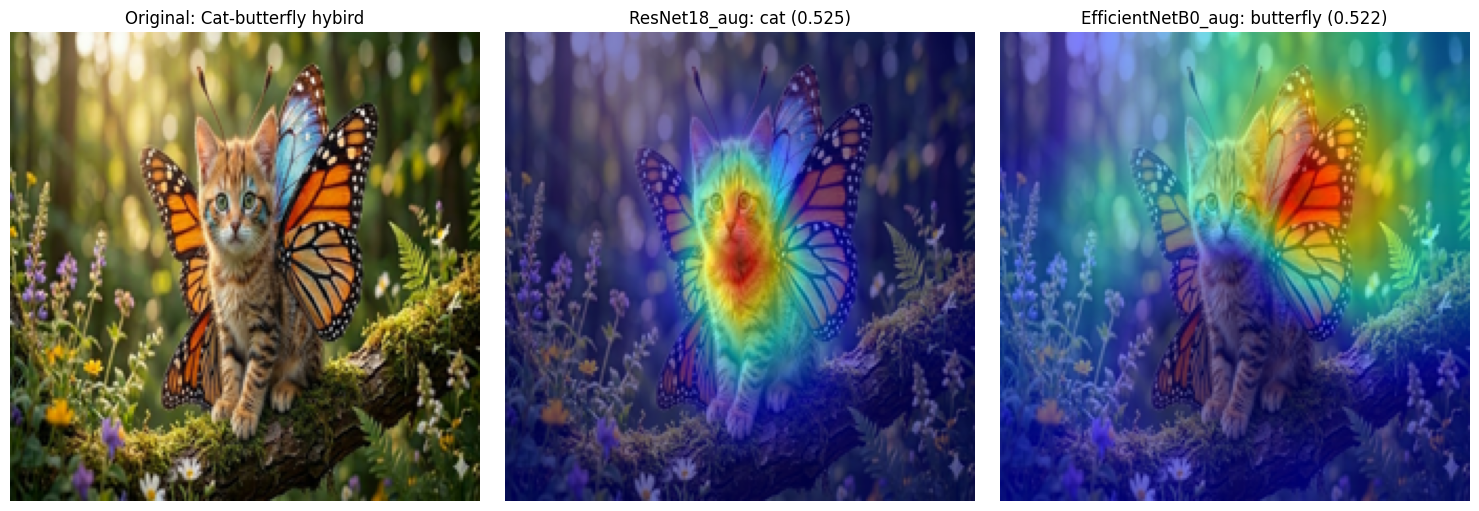

In [ ]:
# model1_name = "ResNet18_aug"
# model2_name = "EfficientNetB0_aug"

# model1, key1 = load_saved_model(model1_name)
# model2, key2 = load_saved_model(model2_name)

# transform = get_transforms(key1, augment=False)

# img_path = "./test.png"

# compare_gradcam(
#     model1, key1,model1_name,
#     model2, key2,model2_name,
#     img_path,
#     'Cat-butterfly hybird',
#     transform
# )

In [42]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from PIL import Image
import torchvision.transforms as transforms
from pytorch_grad_cam import EigenCAM

# ──────────────────────────────────────────────────────────────
# HELPERS
# ──────────────────────────────────────────────────────────────

def load_image(img_path, img_size=224):
    img_pil = Image.open(img_path).convert("RGB")
    img_np  = np.array(img_pil.resize((img_size, img_size))).astype(np.float32) / 255.0
    tf = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std =[0.229, 0.224, 0.225]),
    ])
    return img_np, tf(img_pil).unsqueeze(0)


def normalize_map(arr):
    mn, mx = arr.min(), arr.max()
    return (arr - mn) / (mx - mn + 1e-8)


def upsample_and_overlay(img_np, saliency, alpha=0.6, cmap="jet"):
    h, w    = img_np.shape[:2]
    t       = torch.tensor(saliency).unsqueeze(0).unsqueeze(0).float()
    t       = F.interpolate(t, size=(h, w), mode="bilinear", align_corners=False)
    sal_up  = t.squeeze().numpy()
    heatmap = plt.get_cmap(cmap)(sal_up)[:, :, :3]
    overlay = np.clip((1 - alpha) * img_np + alpha * heatmap, 0, 1)
    return sal_up, overlay


def get_pred(model, input_tensor):
    device = next(model.parameters()).device
    with torch.no_grad():
        logits    = model(input_tensor.to(device))
        pred_idx  = logits.argmax(dim=1).item()
        pred_conf = logits.softmax(dim=1)[0, pred_idx].item()
    return pred_idx, CLASS_NAMES[pred_idx], pred_conf


# ──────────────────────────────────────────────────────────────
# EigenCAM — ViT
#   - Truyền model.backbone (timm ViT) trực tiếp vào EigenCAM
#     thay vì AnimalClassifier wrapper
#   - backbone có .blocks[-1].norm1 ở đúng cấp độ
#   - EigenCAM chỉ cần forward qua backbone để lấy feature map,
#     không cần logits → không bị chặn bởi custom head
# ──────────────────────────────────────────────────────────────

def get_eigencam_vit(model, input_tensor, target_class=None):
    model.eval()
    device = next(model.parameters()).device
    inp    = input_tensor.to(device)
    pred_idx, pred_class, pred_conf = get_pred(model, inp)

    backbone   = model.backbone   # timm ViT, num_classes=0
    patch_grid = 14

    def vit_reshape_transform(tensor):
        # tensor: [B, N, C] = [B, 197, 768]
        # Bỏ CLS token → [B, 196, C] → [B, 14, 14, C] → [B, C, 14, 14]
        result = tensor[:, 1:, :]
        result = result.reshape(tensor.size(0), patch_grid, patch_grid, tensor.size(2))
        result = result.permute(0, 3, 1, 2)
        return result

    cam = EigenCAM(
        model=backbone,                          # ← backbone trực tiếp, không phải wrapper
        target_layers=[backbone.blocks[-1].norm1],
        reshape_transform=vit_reshape_transform,
    )

    grayscale_cam = cam(input_tensor=inp)[0]     # [224, 224]
    return normalize_map(grayscale_cam), pred_class, pred_conf


# ──────────────────────────────────────────────────────────────
# EigenCAM — Swin
#
# Swin Tiny có 4 stages, feature map shrink dần:
#   Stage 0,1: [B, 56*56, C]  (window 7×7 → 8×8 windows)
#   Stage 2:   [B, 28*28, C]
#   Stage 3:   [B,  7* 7, C]  ← dùng stage cuối
#
# reshape_transform: [B, 49, C] → [B, C, 7, 7]
# Dùng backbone trực tiếp (không qua head)
# ──────────────────────────────────────────────────────────────

def get_eigencam_swin(model, input_tensor, target_class=None):
    model.eval()
    device = next(model.parameters()).device
    inp    = input_tensor.to(device)
    pred_idx, pred_class, pred_conf = get_pred(model, inp)

    backbone     = model.backbone   # timm Swin, num_classes=0
    spatial_grid = 7

    def swin_reshape_transform(tensor):
        # tensor: [B, N, C] = [B, 49, 768] (stage cuối Swin-Tiny, 7×7 tokens)
        # → [B, 7, 7, C] → [B, C, 7, 7]
        B, N, C  = tensor.shape
        h = w    = int(N ** 0.5)        # 7
        result   = tensor.reshape(B, h, w, C)
        result   = result.permute(0, 3, 1, 2)   # [B, C, 7, 7]
        return result

    # Target layer: norm2 của block cuối trong stage cuối
    # output shape [B, 49, 768] — trước khi Swin pooling về [B, 768]
    target_layer = backbone.layers[-1].blocks[-1].norm2

    cam = EigenCAM(
        model=backbone,
        target_layers=[target_layer],
        reshape_transform=swin_reshape_transform,
    )

    grayscale_cam = cam(input_tensor=inp)[0]    # [224, 224]
    return normalize_map(grayscale_cam), pred_class, pred_conf



def get_saliency(model, input_tensor, model_key
                , target_class=None, n_steps=50):
    """
    method="auto"/"eigencam" → EigenCAM (ViT/Swin)
    method="ig"             → Integrated Gradients
    """
    is_vit  = "ViT" in model_key
    is_swin = "SwinT" in model_key or "Swin" in model_key

    if is_vit:
        return get_eigencam_vit(model, input_tensor,
                                target_class=target_class)
    elif is_swin:
        return get_eigencam_swin(model, input_tensor,
                                    target_class=target_class)
    else:
        print(f"[WARN] Không nhận ra {model_key}")


def compare_cam(img_path, true_label,
                   model1, model1_key,model1_name,
                   model2, model2_key,model2_name, alpha=0.6, cmap="jet", n_steps=50):
    img_np, input_tensor = load_image(img_path)
    records = []
    for model, mkey in [(model1, model1_key), (model2, model2_key)]:
        model.eval()
        saliency, pred_class, pred_conf = get_saliency(
            model, input_tensor, mkey, n_steps=n_steps,
        )
        _, overlay = upsample_and_overlay(img_np, saliency, alpha=alpha, cmap=cmap)
        records.append((overlay, pred_class, pred_conf))

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    # fig.suptitle(f"Compare: {model1_key} vs {model2_key}  (method=EigenCAM)", fontsize=14)
    axes[0].imshow(img_np); axes[0].set_title(f"Original: {true_label}", fontsize=12); axes[0].axis("off")
    for i, (overlay, pred_class, pred_conf) in enumerate(records):
        key = [model1_name, model2_name][i]
        axes[i+1].imshow(overlay)
        axes[i+1].set_title(f"{key} - Pred: {pred_class} ({pred_conf:.3%})", fontsize=11)
        axes[i+1].axis("off")
    plt.tight_layout()
    plt.show()

# Run comparision

# img_path = "./test.png"
# img_path = "/content/datasets/raw-img/mucca/OIP-23QYWRqZWjK4nDB3NVwx4AHaFj.jpeg"
# print("=== ViT — EigenCAM chi tiết ===")
# visualize_captum(img_path, model3, key3, method="gradcam")

In [48]:
model3_name = "ViT_B16_aug"
model4_name = "SwinT_aug"
model3, key3 = load_saved_model(model3_name)
model4, key4 = load_saved_model(model4_name)

print("=== ViT vs Swin ===")
for idx in wrong_idx:
    img_path, label = test_ds.base_ds.samples[test_ds.indices[idx]]
    compare_cam(img_path, CLASS_NAMES[label], model3, key3, model3_name, model4, key4, model4_name)

Output hidden; open in https://colab.research.google.com to view.

ViT_B16 SwinT


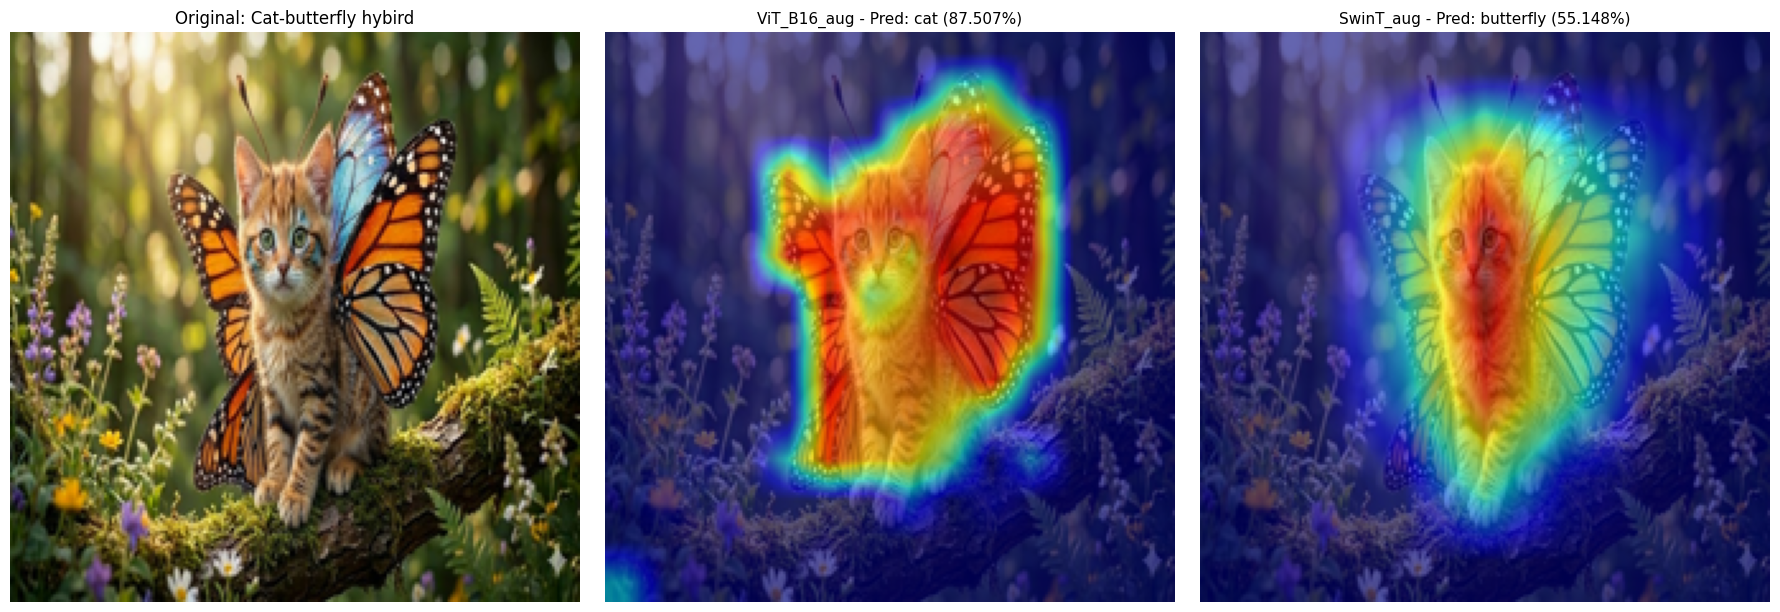

In [ ]:
# model3_name = "ViT_B16_aug"
# model4_name = "SwinT_aug"
# model3, key3 = load_saved_model(model3_name)
# model4, key4 = load_saved_model(model4_name)
# print(key3,key4)
# img_path, label = "./test.png", "Cat-butterfly hybird"
# compare_cam(img_path, label, model3, key3, model3_name, model4, key4, model4_name)

In [49]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from PIL import Image
import torchvision.transforms as transforms


def visualize_pca_heatmap(img_path, model, model_key, img_size=224, n_components=3):
    """
    Extract feature map from last transformer block,
    run PCA, and visualize the first n_components as heatmaps.

    Args:
        img_path:     path to image
        model:        AnimalClassifier (with .backbone)
        model_key:    "ViT_B16_aug" or "SwinT_aug"
        img_size:     input resolution (default 224)
        n_components: number of PCs to visualize (default 3)
    """
    model.eval()
    device = next(model.parameters()).device
    backbone = model.backbone

    # ── 1. Load image ──────────────────────────────────────────
    img_pil = Image.open(img_path).convert("RGB")
    img_np  = np.array(img_pil.resize((img_size, img_size))).astype(np.float32) / 255.0
    tf = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std =[0.229, 0.224, 0.225]),
    ])
    input_tensor = tf(img_pil).unsqueeze(0).to(device)

    # ── 2. Hook to capture feature map ─────────────────────────
    features = {}

    def hook_fn(module, input, output):
        features["feat"] = output.detach()  # [B, N, C]

    is_vit  = "ViT"  in model_key
    is_swin = "Swin" in model_key

    if is_vit:
        handle = backbone.blocks[-1].norm1.register_forward_hook(hook_fn)
        patch_grid = img_size // 16   # 14 for 224px ViT-B/16
    elif is_swin:
        handle = backbone.layers[-1].blocks[-1].norm2.register_forward_hook(hook_fn)
        patch_grid = img_size // 32   # 7 for 224px Swin-Tiny

    with torch.no_grad():
        backbone(input_tensor)
    handle.remove()

    # ── 3. Reshape tokens → spatial grid ───────────────────────
    feat = features["feat"]   # [B, N, C]

    if is_vit:
        feat = feat[:, 1:, :]  # drop CLS token → [B, 196, C]

    B, N, C = feat.shape
    h = w   = int(N ** 0.5)   # should equal patch_grid
    feat_2d = feat[0].cpu().numpy()   # [N, C]

    # ── 4. PCA via SVD ─────────────────────────────────────────
    # Center the feature matrix (important for PCA)
    feat_centered = feat_2d - feat_2d.mean(axis=0, keepdims=True)  # [N, C]
    U, S, Vt = np.linalg.svd(feat_centered, full_matrices=False)

    # Project tokens onto top-n PCs → [N, n_components]
    projections = feat_centered @ Vt[:n_components].T   # [N, n_components]

    # ── 5. Plot ────────────────────────────────────────────────
    fig, axes = plt.subplots(1, n_components + 1, figsize=(5 * (n_components + 1), 5))
    fig.suptitle(f"{model_key} — PCA of feature map at last block\n"
                 f"Grid: {h}×{w}, Channels: {C}", fontsize=13)

    # Original image
    axes[0].imshow(img_np)
    axes[0].set_title("Original image")
    axes[0].axis("off")

    # Each PC heatmap
    for i in range(n_components):
        pc_map = projections[:, i].reshape(h, w)   # [H, W]

        # Upsample to image size
        t     = torch.tensor(pc_map).unsqueeze(0).unsqueeze(0).float()
        t     = F.interpolate(t, size=(img_size, img_size),
                              mode="bilinear", align_corners=False)
        pc_up = t.squeeze().numpy()

        # Normalize to [0, 1] for display
        mn, mx = pc_up.min(), pc_up.max()
        pc_norm = (pc_up - mn) / (mx - mn + 1e-8)

        im = axes[i + 1].imshow(pc_norm, cmap="jet")
        axes[i + 1].set_title(
            f"PC{i+1}  (singular value: {S[i]:.1f})\n"
            f"{'← this is EigenCAM' if i == 0 else ''}"
        )
        axes[i + 1].axis("off")
        plt.colorbar(im, ax=axes[i + 1], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

    # ── 6. Print variance explained ────────────────────────────
    variance_explained = (S ** 2) / (S ** 2).sum() * 100
    print("Variance explained by each PC:")
    for i in range(n_components):
        print(f"  PC{i+1}: {variance_explained[i]:.2f}%")
    print(f"  Top-{n_components} total: {variance_explained[:n_components].sum():.2f}%")

    return projections, S, Vt

In [60]:
# model_name = 'SwinT_aug'
# model, key = load_saved_model(model_name)
# for idx in wrong_idx:
#     img_path, label = test_ds.base_ds.samples[test_ds.indices[idx]]
#     projections, S, Vt = visualize_pca_heatmap(img_path, model, model_name)

In [63]:
def visualize_image_pca(img_path, img_size=224, n_components=3):
    """
    Run PCA directly on raw image pixels.
    Image is treated as a matrix of shape [H*W, 3] (3 RGB channels).
    """
    # ── 1. Load & reshape ──────────────────────────────────────
    img_pil = Image.open(img_path).convert("RGB")
    img_np  = np.array(img_pil.resize((img_size, img_size))).astype(np.float32) / 255.0
    # [H, W, 3] → [N, 3] where N = H*W
    pixels  = img_np.reshape(-1, 3)   # [50176, 3]

    # ── 2. PCA ─────────────────────────────────────────────────
    pixels_centered = pixels - pixels.mean(axis=0, keepdims=True)
    U, S, Vt = np.linalg.svd(pixels_centered, full_matrices=False)

    for i in range(len(Vt)):
        if Vt[i].mean() < 0:
            Vt[i] = -Vt[i]
    # Project pixels onto top PCs → [N, n_components]
    projections = pixels_centered @ Vt[:n_components].T
    print("debug:",Vt[0])
    # ── 3. Plot ────────────────────────────────────────────────
    fig, axes = plt.subplots(1, n_components + 1, figsize=(5 * (n_components + 1), 5))

    axes[0].imshow(img_np)
    axes[0].set_title("Original")
    axes[0].axis("off")

    variance_explained = (S ** 2) / (S ** 2).sum() * 100

    for i in range(n_components):
        pc_map  = projections[:, i].reshape(img_size, img_size)
        mn, mx  = pc_map.min(), pc_map.max()
        pc_norm = (pc_map - mn) / (mx - mn + 1e-8)

        im = axes[i+1].imshow(pc_norm, cmap="jet")
        axes[i+1].set_title(f"PC{i+1}  ({variance_explained[i]:.1f}% var)")
        axes[i+1].axis("off")
        plt.colorbar(im, ax=axes[i+1], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

In [64]:
for idx in wrong_idx:
    img_path, label = test_ds.base_ds.samples[test_ds.indices[idx]]
    visualize_image_pca(img_path)

Output hidden; open in https://colab.research.google.com to view.